##### ***编码器-解码器架构***
###### 正如前文所说，机器翻译是序列转化模型的一个核心问题，其输入和输出都是长度可变的序列，而为了处理这种输入输出不对齐的序列，我们考虑有没有一种架构可以在输入和输出之间建立一个新状态，既压缩了输入的语义又能让输出根据这个状态进行生成。据此，产生了编码器-解码器架构。第一个组件是一个编码器（encoder）：它接受一个长度可变的序列作为输入，并将其转换为具有固定形状的编码状态。第二个组件是解码器（decoder）：它将固定形状的编码状态映射到长度可变的序列。这被称为编码器-解码器（encoder-decoder）架构。
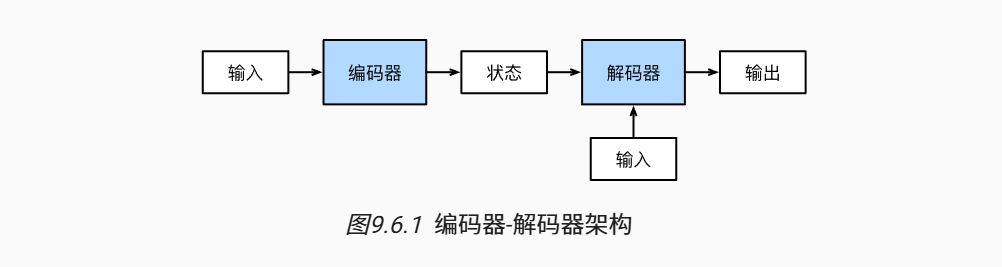

In [1]:
from torch import nn

class Encoder(nn.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def forward(self, X, *args):
        raise NotImplementedError

In [2]:
class Decoder(nn.Module):
    def __init__(self, **kwargs):
        super(Decoder, self).__init__(**kwargs)
    # 解码器中新增一个init_state函数，用于将编码器的输出转换为编码后的状态。
    def init_state(self, enc_outputs, *args):
        raise NotImplementedError
    def forward(self, X, state):
        raise NotImplementedError

In [3]:
class EncoderDecoder(nn.Module):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, enc_x, dec_x, *args):
        enc_outputs = self.encoder(enc_x, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_x, dec_state)